In [7]:
import sys
sys.path.append('/Users/pp/Documents/Repos/plant_hydro_standalone/cpp/cmake-build-release')

from hydro_standalone import Simulation_Single_Swiss
from hydro_standalone import Simulation_Multi_Swiss
from hydro_standalone import DateTime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datetime
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import  os

range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

soil_variants = ['PR', 't2']
soil_variants = ['PR']

id = 4544510
rt_path = f"cond_alivegrp_12_no_psi_stem_H_{id}"
rt_path = f"cond_alivegrp_12_no_psi_stem_H_no_lai_{id}"
rt_path = f"cond_alivegrp_12_var_psiL_full_psiX_{id}"

if not os.path.isdir(rt_path):
    os.mkdir(rt_path)

In [8]:
forcing_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Forcing_Inter.csv"
path_of_the_trees = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Trees"

In [12]:
treedata = TreeWaterPotData()
trees = treedata.trees

In [13]:
trees[0].dates

(array(['2018-06-05T00:00:00.000000000', '2018-06-14T00:00:00.000000000',
        '2018-06-20T00:00:00.000000000', '2018-07-16T00:00:00.000000000',
        '2018-08-03T00:00:00.000000000', '2018-08-08T00:00:00.000000000',
        '2018-08-16T00:00:00.000000000', '2018-09-05T00:00:00.000000000',
        '2018-09-18T00:00:00.000000000'], dtype='datetime64[ns]'),)

In [14]:
from enum import Enum

class State(Enum):
    Alive = 0
    Dead = 1


In [15]:
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv"
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv"

theta_files = []
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv")
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv")

psi_stem_init = -0.8
psi_leaf_init = -1.5


states = [State.Alive, State.Dead]


alive_state = [True, False]


for sv_i in range(len(soil_variants)):

    for state in states:

        if state == State.Alive:
            vals = [0]
        else:
            vals = range_dead

        for k in vals:

            if state == State.Alive:
                parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_params_all_alive.csv"
            else:
                if k == 7:
                    parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_fix.csv"
                else:
                    parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}.csv"

            df_i = pd.read_csv(parameter_input_file_list)
            sim = Simulation_Single()

            n = df_i.shape[0]
            x = np.linspace(0, n - 1 , num = 10).astype(int)


            fig = plt.figure(figsize=(12, 6))
            ax = fig.add_subplot(3,1,1)
            ax2 = fig.add_subplot(3,1,2)
            ax3 = fig.add_subplot(3,1,3)

            #for i in range(0, 1000, 25):
            for i in range(0, 1000, 20):


                sim.Init_parameters_fn_single(parameter_input_file_list, i)

                sim.Init_input(theta_files[sv_i], forcing_file, path_of_the_trees)
                sim.Set_water_pot_initials(psi_leaf_init, psi_stem_init)

                steplen = 30
                timestart = 30 * 2 * 24 * 0.0
                timeend = 30 * 2 * 24 * 213


                sim.Run(steplen, timestart, timeend)
                output = sim.Get_output()

                if i == 0:
                    times = output.Get_times()

                    df = pd.DataFrame(times, columns= ['DeltaT'])

                    df_swc_raw = pd.read_csv(theta_files[sv_i])
                    dates = df_swc_raw['Unnamed: 0'][:-1]

                    offset_date_str  = dates[0]
                    offset_date = datetime.datetime.strptime(offset_date_str, '%Y-%m-%d %H:%M:%S')

                    df['date'] = [offset_date + datetime.timedelta(seconds = int(i * 30 * 2)) for i in df['DeltaT'].values]
                    df.reset_index()
                    df.set_index('date')

                psi_leaf = output.Get_psi_leaf()
                psi_stem = output.Get_psi_stem()

                df['psi_stem']= psi_stem
                df['psi_leaf']= psi_leaf
                psi_soil_upper = np.array(output.Get_psi_soil_indiv())[:,0]

                df['psi_soil_upper']= psi_soil_upper
                ax.plot(df['date'], df['psi_stem'], zorder = 0)
                ax2.plot(df['date'], df['psi_leaf'], zorder = 0)
                ax3.plot(df['date'], df['psi_soil_upper'], zorder = 0)
                if state == State.Dead:
                    ax.set_ylim((-7.5, 0))
                    ax2.set_ylim((-7.5, 0))




            if state == State.Alive:
                for s in range_alive:
                    ax2.scatter(trees[s].dates, trees[s].xylem_pressure , c = 'black', zorder = 1)
            else:
                ax2.scatter(trees[k].dates, trees[k].xylem_pressure , c = 'black', zorder = 1)




            plt.savefig(f"{rt_path}/{soil_variants[sv_i]}_{str(state)}_{k}.png", dpi = 300)
            plt.close()
            print(k)

0
0
3
6
7


In [20]:
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv"
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv"

theta_files = []
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv")
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv")

psi_stem_init = -0.8
psi_leaf_init = -1.5


states = [State.Alive, State.Dead]


alive_state = [True, False]


for sv_i in range(len(soil_variants)):

    for state in states:

        if state == State.Alive:
            vals = [0]
        else:
            vals = range_dead

        for k in vals:

            if state == State.Alive:
                parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_params_all_alive.csv"
            else:
                if k == 7:
                    parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}_fix.csv"
                else:
                    parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}.csv"

            df_i = pd.read_csv(parameter_input_file_list)
            sim = Simulation_Single()

            n = df_i.shape[0]
            x = np.linspace(0, n - 1 , num = 10).astype(int)




            data_psi_L = np.zeros((10224, 50))
            data_psi_S = np.zeros((10224, 50))

            ir = 0

            #for i in range(0, 1000, 25):
            for i in range(0, 500, 10):


                sim.Init_parameters_fn_single(parameter_input_file_list, i)

                sim.Init_input(theta_files[sv_i], forcing_file, path_of_the_trees)
                sim.Set_water_pot_initials(psi_leaf_init, psi_stem_init)

                steplen = 30
                timestart = 30 * 2 * 24 * 0.0
                timeend = 30 * 2 * 24 * 213


                sim.Run(steplen, timestart, timeend)
                output = sim.Get_output()

                if i == 0:
                    times = output.Get_times()

                    df = pd.DataFrame(times, columns= ['DeltaT'])

                    df_swc_raw = pd.read_csv(theta_files[sv_i])
                    dates = df_swc_raw['Unnamed: 0'][:-1]

                    offset_date_str  = dates[0]
                    offset_date = datetime.datetime.strptime(offset_date_str, '%Y-%m-%d %H:%M:%S')

                    df['date'] = [offset_date + datetime.timedelta(seconds = int(i * 30 * 2)) for i in df['DeltaT'].values]
                    df.reset_index()
                    df.set_index('date')

                psi_leaf = output.Get_psi_leaf()
                psi_stem = output.Get_psi_stem()


                data_psi_L[:, ir] = np.array(psi_leaf)
                data_psi_S[:, ir] = np.array(psi_stem)
                ir += 1


            #ax.plot(df['date'], df['psi_stem'], zorder = 0)
            #ax2.plot(df['date'], df['psi_leaf'], zorder = 0)

            if state == State.Alive:
                col = 'blue'
            else:
                col = 'red'

            df_psi_L = pd.DataFrame()
            df_psi_L['median'] = np.median(data_psi_L, axis=1)
            df_psi_L['q25'] = np.quantile(data_psi_L, axis=1, q =0.25)
            df_psi_L['q05'] = np.quantile(data_psi_L, axis=1, q =0.01)
            df_psi_L['q75'] = np.quantile(data_psi_L, axis=1, q =0.75)
            df_psi_L['q95'] = np.quantile(data_psi_L, axis=1, q =0.99)



            df_psi_S = pd.DataFrame()
            df_psi_S['median'] = np.median(data_psi_S, axis=1)
            df_psi_S['q25'] = np.quantile(data_psi_S, axis=1, q =0.25)
            df_psi_S['q05'] = np.quantile(data_psi_S, axis=1, q =0.01)
            df_psi_S['q75'] = np.quantile(data_psi_S, axis=1, q =0.75)
            df_psi_S['q95'] = np.quantile(data_psi_S, axis=1, q =0.99)


            fig = plt.figure(figsize=(12, 6))
            ax = fig.add_subplot(2,2,1)
            ax2 = fig.add_subplot(2,2,3)

            if state == State.Alive:
                for s in range_alive:
                    ax2.scatter(trees[s].dates, trees[s].xylem_pressure , c = 'black', zorder = 1)
            else:
                ax2.scatter(trees[k].dates, trees[k].xylem_pressure , c = 'black', zorder = 1)

            ax2.plot(df['date'] , df_psi_L['median'], color = col, zorder = 0)
            ax2.fill_between(df['date'] , df_psi_L['q25'],  df_psi_L['q75'], color = col, alpha = 0.25, zorder = 0)
            ax2.fill_between(df['date'] , df_psi_L['q05'],  df_psi_L['q95'], color = col, alpha = 0.15, zorder = 0)
            ax2.set_ylabel("$\psi_L$ [MPa]")

            ax.set_ylabel("$\psi_L$ [MPa]")
            ax.plot(df['date'] , df_psi_S['median'], color = col)
            ax.fill_between(df['date'] , df_psi_S['q25'],  df_psi_S['q75'], color = col, alpha = 0.25)
            ax.fill_between(df['date'] , df_psi_S['q05'],  df_psi_S['q95'], color = col, alpha = 0.15)

            if state == State.Dead:
                ax.set_ylim((-7.5, 0))
                ax2.set_ylim((-7.5, 0))

            ax.xaxis.set_tick_params(rotation=45)
            ax2.xaxis.set_tick_params(rotation=45)


            ax = fig.add_subplot(2,2,2)
            ax2 = fig.add_subplot(2,2,4)


            d0 = 15*48
            d1 = 19*48

            df_psi_L = df_psi_L.iloc[d0:d1]
            df_psi_S = df_psi_S.iloc[d0:d1]
            dates = df['date'].iloc[d0:d1]

            ax2.plot(dates , df_psi_L['median'], color = col)
            ax2.fill_between(dates , df_psi_L['q25'],  df_psi_L['q75'], color = col, alpha = 0.25)
            ax2.fill_between(dates , df_psi_L['q05'],  df_psi_L['q95'], color =col, alpha = 0.15)
            ax2.set_ylabel("$\psi_L$ [MPa]")

            ax.set_ylabel("$\psi_S$ [MPa]")
            ax.plot(dates , df_psi_S['median'], color = col)
            ax.fill_between(dates, df_psi_S['q25'],  df_psi_S['q75'], color = col, alpha = 0.25)
            ax.fill_between(dates , df_psi_S['q05'],  df_psi_S['q95'], color = col, alpha = 0.15)


            ax.xaxis.set_tick_params(rotation=45)
            ax2.xaxis.set_tick_params(rotation=45)
            # if state == State.Alive:
            #     for s in range_alive:
            #         ax2.scatter(trees[s].dates, trees[s].xylem_pressure , c = 'black', zorder = 1)
            # else:
            #     ax2.scatter(trees[k].dates, trees[k].xylem_pressure , c = 'black', zorder = 1)

            plt.subplots_adjust(hspace=0.5)
            plt.savefig(f"{rt_path}/Average_{soil_variants[sv_i]}_{str(state)}_{k}.png", dpi = 300)
            plt.close()
            print(k)

0
0
3
6
7


In [23]:
data_psi_L

array([[-1.25003147, -1.2769078 , -1.25861502, ..., -1.3369    ,
        -1.29091299, -1.36937642],
       [-0.88982177, -0.92873406, -0.9569332 , ..., -1.11168516,
        -1.02583706, -1.17508841],
       [-0.66615826, -0.70518571, -0.73978758, ..., -0.92050415,
        -0.80733877, -1.00078917],
       ...,
       [-1.03233242, -0.97824812, -0.81912935, ..., -1.14199638,
        -1.21233356, -1.22277713],
       [-1.02968585, -0.97498983, -0.81728256, ..., -1.13981044,
        -1.21004701, -1.22014022],
       [-1.02710998, -0.97181773, -0.8154934 , ..., -1.13768792,
        -1.20783865, -1.21758258]])

ValueError: x and y must have same first dimension, but have shapes (10224,) and (192,)

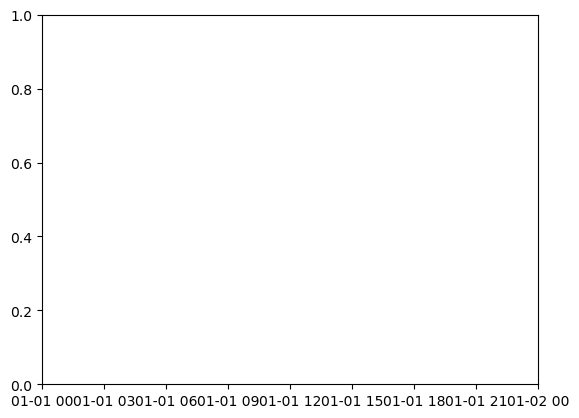

In [18]:
plt.plot(df['date'] , df_psi_L['median'], color = 'blue')

In [68]:
df['date'].iloc[0:4*48]

0     2018-06-01 00:00:00
1     2018-06-01 00:30:00
2     2018-06-01 01:00:00
3     2018-06-01 01:30:00
4     2018-06-01 02:00:00
              ...        
187   2018-06-04 21:30:00
188   2018-06-04 22:00:00
189   2018-06-04 22:30:00
190   2018-06-04 23:00:00
191   2018-06-04 23:30:00
Name: date, Length: 192, dtype: datetime64[ns]

In [37]:
df_psi_L = pd.DataFrame()
df_psi_L['median'] = np.median(data_psi_L, axis=1)
df_psi_L['q25'] = np.quantile(data_psi_L, axis=1, q =0.25)
df_psi_L['q05'] = np.quantile(data_psi_L, axis=1, q =0.05)
df_psi_L['q75'] = np.quantile(data_psi_L, axis=1, q =0.75)
df_psi_L['q95'] = np.quantile(data_psi_L, axis=1, q =0.95)

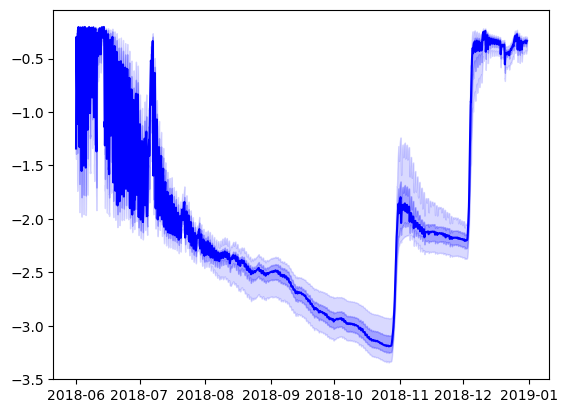

In [54]:
plt.plot(df['date'] , df_psi_L['median'], color = 'blue')
plt.fill_between(df['date'] , df_psi_L['q25'],  df_psi_L['q75'], color = 'blue', alpha = 0.25)
plt.fill_between(df['date'] , df_psi_L['q05'],  df_psi_L['q95'], color = 'blue', alpha = 0.15)

In [38]:
df_psi_L

,median,q25,q05,q75,q95
0,-1.341724,-1.392159,-1.438985,-1.318207,-1.263297
1,-1.129951,-1.244132,-1.338387,-1.059481,-0.945805
2,-0.928393,-1.091293,-1.232123,-0.838199,-0.695233
3,-0.760476,-0.950958,-1.131009,-0.664357,-0.521784
4,-0.627363,-0.828084,-1.038116,-0.535978,-0.405003
...,...,...,...,...,...
10219,-0.338007,-0.359971,-0.425729,-0.316341,-0.297608
10220,-0.337402,-0.359465,-0.424976,-0.316089,-0.297214
10221,-0.336897,-0.359022,-0.424314,-0.315901,-0.297021
10222,-0.336472,-0.358630,-0.423725,-0.315750,-0.296864


In [ ]:
s